# ⭐ EDA: Performance Benchmarks & Training Program Impact

Analyzing employee productivity metrics, promotion criteria, and training program return on investment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

BASE_DIR = Path('..').resolve()
sys.path.append(str(BASE_DIR))
from app.backend.config import *

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

### 1. Load Performance and Training Data

In [2]:
df_perf = pd.read_csv(DATA_PROCESSED_DIR / 'processed_performance.csv')
df_train = pd.read_csv(DATA_PROCESSED_DIR / 'processed_training_engagement.csv')
print(f'Performance Shape: {df_perf.shape}')
print(f'Training Shape: {df_train.shape}')

Performance Shape: (5000, 18)
Training Shape: (2845, 31)


### 2. Performance & Promotion Distribution

C:\Users\hs264\AppData\Local\Temp\ipykernel_2708\3276080775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_perf, x='Promotion Eligibility', y='ProductivityIndex', ax=axes[0], palette='Blues')


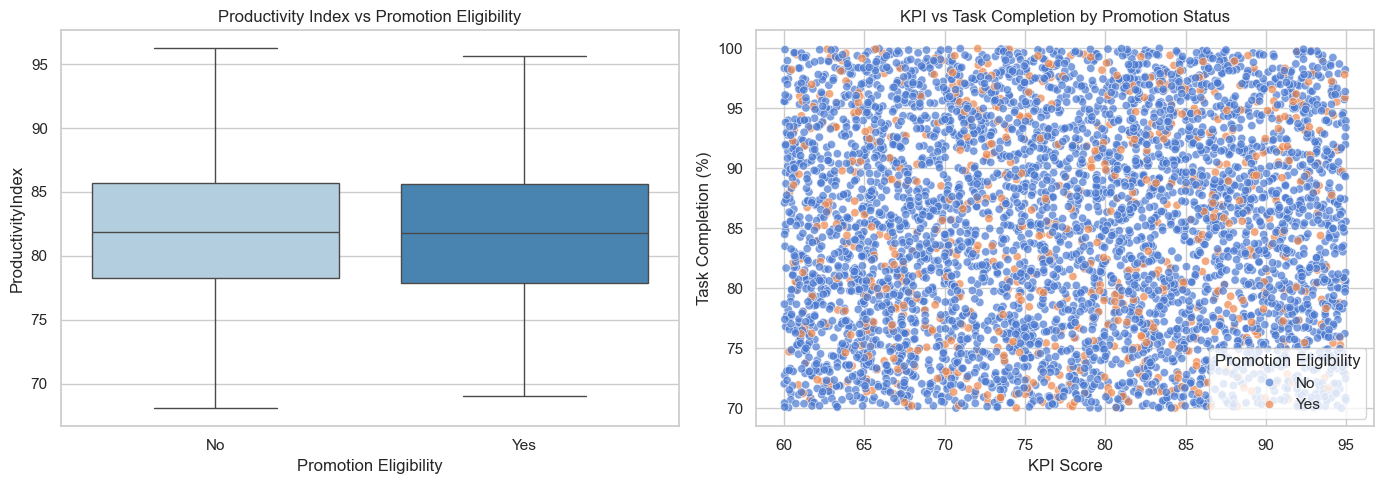

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Productivity Index by Promotion
sns.boxplot(data=df_perf, x='Promotion Eligibility', y='ProductivityIndex', ax=axes[0], palette='Blues')
axes[0].set_title('Productivity Index vs Promotion Eligibility')

# KPI Score vs Task Completion
sns.scatterplot(data=df_perf, x='KPI Score', y='Task Completion (%)', hue='Promotion Eligibility', alpha=0.7, ax=axes[1])
axes[1].set_title('KPI vs Task Completion by Promotion Status')

plt.tight_layout()
plt.show()

### 3. Training Program Outcomes & Success Rates

In [4]:
train_summary = df_train.groupby('Training Program Name').agg(
    Total_Enrolled=('Training Outcome', 'count'),
    Success_Rate=('TrainingSuccess', 'mean'),
    Avg_Cost=('Training Cost', 'mean'),
    Avg_Duration=('Training Duration(Days)', 'mean')
).reset_index()

train_summary['Success_Rate (%)'] = (train_summary['Success_Rate'] * 100).round(1)
train_summary['Avg_Cost ($)'] = train_summary['Avg_Cost'].round(2)
train_summary.sort_values(by='Success_Rate (%)', ascending=False)

,Training Program Name,Total_Enrolled,Success_Rate,Avg_Cost,Avg_Duration,Success_Rate (%),Avg_Cost ($)
0,Communication Skills,633,0.543444,544.303318,2.963665,54.3,544.30
1,Customer Service,540,0.535185,569.882463,2.970370,53.5,569.88
2,Leadership Development,544,0.531250,561.423658,3.022059,53.1,561.42
3,Project Management,585,0.476923,562.922735,3.003419,47.7,562.92
4,Technical Skills,543,0.451197,560.117551,2.909761,45.1,560.12


### 4. Training Spend by Department & Division

C:\Users\hs264\AppData\Local\Temp\ipykernel_2708\2008389541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_spend.values, y=dept_spend.index, palette='viridis')


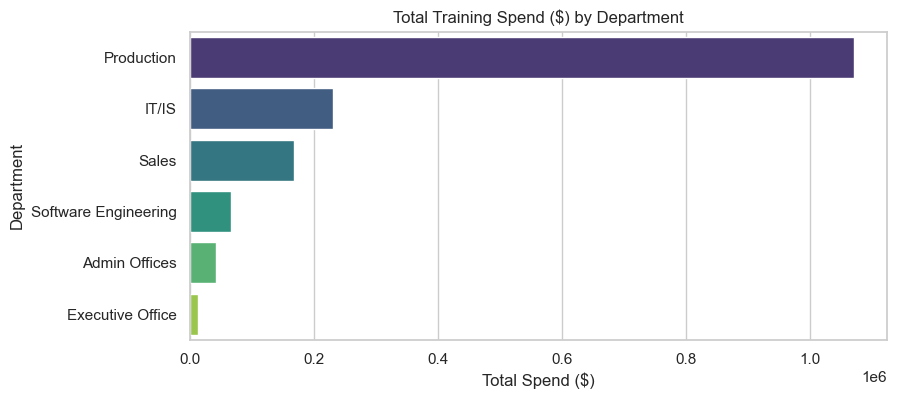

In [5]:
dept_spend = df_train.groupby('DepartmentType')['Training Cost'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=dept_spend.values, y=dept_spend.index, palette='viridis')
plt.title('Total Training Spend ($) by Department')
plt.xlabel('Total Spend ($)')
plt.ylabel('Department')
plt.show()